## 端到端机器学习项目
---

* 端到端机器学习项目的主要步骤：
    1. 框定问题
        1. 任务目标是什么
        2. 当前的解决方案是什么样的（如果有）
        3. 设计你的系统
    2. 选择性能指标
        * RMSE-均方根误差
        * MAE-平均绝对误差
    3. 检查假设

---

### 补充知识点
* 数据流水线
    * 定义：一系列数据处理组件称为数据流水线

In [1]:
# 获取和加载数据的函数
from pathlib import Path # 用面向对象的方式处理路径（跨 Windows/Linux/macOS 更稳），例如拼路径、判断文件是否存在、创建目录等。
import pandas as pd # 读取 CSV 并返回 DataFrame。
import tarfile # 用于打开和解压 .tgz（本质是 tar + gzip）压缩包。
import urllib.request # 标准库的下载工具，用于把 URL 指向的文件下载到本地。

# 定义一个无参数函数，默认把数据放到当前工作目录下的 datasets/ 中。
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz") # 1. 定义压缩包路径
    # 2. 判断本地是否已存在压缩包；不存在就下载
    if not tarball_path.is_file():
        # 创建目录：
        Path("datasets").mkdir(parents=True, exist_ok=True) # parents=True：如果中间目录不存在（例如 datasets/），自动递归创建；exist_ok=True：如果目录已经存在，不报错。
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path) # 下载：从 url 下载文件到本地 tarball_path。
        # 3. 打开压缩包并解压到 datasets 目录
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets") # extractall(path="datasets")：把压缩包里所有内容解压到 datasets/ 目录下。
    return pd.read_csv("datasets/housing/housing.csv")

housing = load_housing_data()

# 快速浏览数据结构
1. `DataFrame.head()` # 查看数据的前五行
2. `DataFrame.info()` # 快速描述 DataFrame 的**结构信息**，包括行数、列数、列类型、非空数量、内存占用等。
3. `DataFrame['attribute'].value_counts` # 用于**统计某一列中各取值出现的频数，并按出现次数从高到低排序**返回结果。
4. `DataFrame.describe()` # 用于对 **数值型特征** 进行统计描述
5. `DataFrame.hist()` # 为每个数值属性绘制直方图

In [3]:
# .head() 查看数据的前五行
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# info() 快速描述 DataFrame 的结构信息，包括行数、列数、列类型、非空数量、内存占用等。
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


---

# 📊 1. `housing_data.info()` 简易笔记

## 1. `info()` 的作用

`DataFrame.info()` 用于**快速查看数据集的整体结构**，主要包括：

* 样本数量（行数）
* 特征数量（列数）
* 每一列的数据类型（dtype）
* 每一列的非空值数量
* 是否存在缺失值
* 数据集的内存占用情况

该方法常用于 **数据读取后的第一步检查（数据体检）**。

---

## 2. 数据集整体信息

```text
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
```

* 数据类型：`pandas.DataFrame`
* 样本数量：**20640 条**
* 索引范围：`0 ~ 20639`（默认整数索引）
* 特征数量：**10 个**

---

## 3. 各列字段信息

| 序号 | 字段名                | 非空数量  | 数据类型    | 说明          |
| -- | ------------------ | ----- | ------- | ----------- |
| 0  | longitude          | 20640 | float64 | 经度          |
| 1  | latitude           | 20640 | float64 | 纬度          |
| 2  | housing_median_age | 20640 | float64 | 房屋中位年龄      |
| 3  | total_rooms        | 20640 | float64 | 房间总数        |
| 4  | total_bedrooms     | 20433 | float64 | 卧室总数（存在缺失）  |
| 5  | population         | 20640 | float64 | 人口数量        |
| 6  | households         | 20640 | float64 | 家庭数量        |
| 7  | median_income      | 20640 | float64 | 收入中位数       |
| 8  | median_house_value | 20640 | float64 | 房价中位数（预测目标） |
| 9  | ocean_proximity    | 20640 | object  | 距离海洋的类别特征   |

---

## 4. 缺失值情况

* `total_bedrooms` 列存在缺失值
* 缺失数量：
  [
  20640 - 20433 = 207
  ]

> 该列在建模前需要进行 **缺失值处理（如中位数填补）**。

---

## 5. 数据类型分布

```text
dtypes: float64(9), object(1)
```

* 数值型特征：**9 列（float64）**
* 类别型特征：**1 列（object）**

其中：

* `ocean_proximity` 为类别特征，需在建模前进行编码（如 One-Hot Encoding）。

---

## 6. 内存占用情况

```text
memory usage: 1.6+ MB
```

* 数据集体量较小
* 适合进行探索性分析（EDA）和传统机器学习模型训练

---

## 7. 小结

* 该数据集为 **典型的回归问题数据**
* 存在 **少量缺失值**
* 同时包含 **数值特征与类别特征**
* 在建模前需要进行：

  * 缺失值处理
  * 类别特征编码
  * （可选）特征缩放

---



# 2. `value_counts()`
* 查看9   ocean_proximity     20640 non-null  object 的类型为python对象，由于是从csv文件中加载的，所以确定它为文本属性
* 使用value_counts()方法找出存在哪些类型以及每个类别有多少个地区
    * <1H OCEAN <1小时车程
    * 内陆
    * 靠近海洋
    * 靠近海湾
    * 岛屿

In [5]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

* describe()方法显示数字属性的摘要

---

# 📈 3. `housing.describe()` 简要说明

## 1. 方法作用

`DataFrame.describe()` 用于对 **数值型特征** 进行统计描述，主要包括：

* 非空样本数（count）
* 均值（mean）
* 标准差（std）
* 最小值 / 最大值（min / max）
* 四分位数（25%、50%、75%）

该方法常用于 **探索性数据分析（EDA）阶段**，帮助快速了解数据分布情况。

---

## 2. 样本与缺失值情况

* 数据集总样本数：**20640**
* 所有数值列中，仅：

  * `total_bedrooms` 存在缺失值（20433 条非空）
* 缺失样本数量：**207 条**

---

## 3. 特征分布特征

* 经纬度（`longitude`, `latitude`）显示数据位于 **美国加州区域**
* `housing_median_age` 最大值为 **52**，存在明显的取值上限
* `median_income` 均值约为 **3.87**（单位为标准化收入指标）
* `median_house_value` 均值约为 **20.7 万美元**

---

## 4. 房价特征的重要现象

* `median_house_value` 最大值为 **500001**
* 说明房价数据存在 **人为封顶（截断）现象**
* 高价区域真实房价未被完整反映，可能影响回归模型性能

---

## 5. 建模启示

* 需要对 `total_bedrooms` 进行缺失值处理
* 特征尺度差异较大，线性模型前应进行标准化
* 可通过构造比值特征（如人均房间数）提升模型效果

---

## 6. 小结

`housing.describe()` 揭示了该数据集存在 **缺失值、分布偏态及标签封顶** 等典型问题，为后续 **数据预处理与特征工程** 提供了重要依据。

---


In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# 4. 为每个数值属性绘制直方图 `.hist()`

---

## 2. 功能说明

* `housing.hist()`
  使用 **pandas 内置的直方图方法**，对 DataFrame 中所有 **数值型特征** 自动绘制直方图。
* 每一个数值特征对应一个子图，用于展示其取值分布情况。

---

## 3. 参数解释

* `bins=50`

  * 指定直方图的区间数量（柱子数量）
  * 区间数越多，分布细节越清晰

* `figsize=(12, 8)`

  * 设置整张图的大小（宽 12 英寸，高 8 英寸）
  * 避免子图过于拥挤，提升可读性

* `plt.show()`

  * 显式显示图像
  * 在脚本或 `.py` 文件中是必需的

---

## 4. 使用目的

* 观察各特征的分布形态（是否偏态、长尾分布）
* 发现异常值或数据截断现象
* 为后续特征工程（如对数变换、标准化）提供依据

---

## 5. 注意事项

* 仅对 **数值型列** 生效，`object` 类型不会被绘制
* 常用于 **探索性数据分析（EDA）阶段**

---

## 6. 小结

该代码通过直方图的方式直观展示数据分布，是理解数据结构和制定预处理策略的重要步骤。

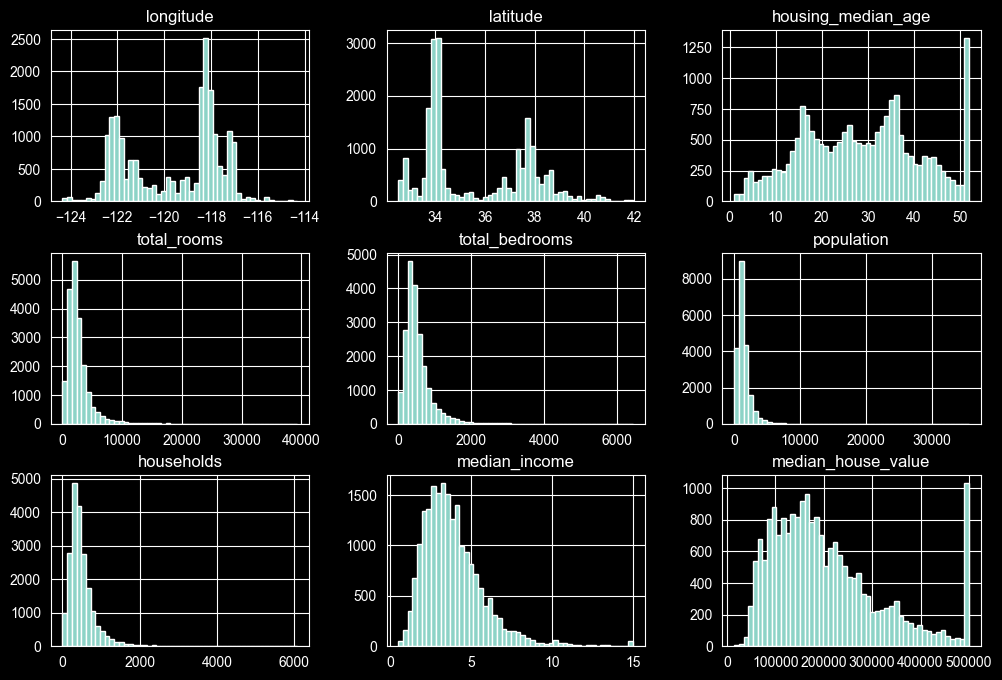

In [7]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(12,8))
plt.show()

# 创建测试集
1. 方式1：根据datasets长度做索引打乱以进行一次性划分，采用np.random.permutation()
2. 方式2：根据index采用crc32方式计算hash值，用以划分数据集
3. 方式3：利用数据特性构建hash值，用以划分数据集
4. 方式4：利用Scikit-learn提供的train_test_split()函数

## 1. 方式1：根据datasets长度做索引打乱以进行一次性划分，采用np.random.permutation()

In [2]:
import numpy as np

# 把数据随机打乱，然后按比例切分为训练集与测试集
# data：通常是一个 pandas.DataFrame
# test_ratio：测试集占比（例如 0.2 表示 20% 为测试集）

# 设置随机种子
np.random.seed(42)

def shuffle_and_split_data(data, test_ratio):
    # 断言：测试集比例必须在 (0, 1) 之间
    assert 0 < test_ratio < 1, "test_ratio must be between 0 and 1 (exclusive)."

    # np.random.permutation(n)：生成 0 ~ n-1 的一个随机排列数组
    shuffled_indices = np.random.permutation(len(data)) # len(data)：数据的行数（样本数）
    test_set_size = int(len(data) * test_ratio) # 计算测试集大小

    # 断言：测试集大小必须大于 0 且小于总样本数
    assert 0 < test_set_size < len(data), "Invalid test set size computed."

    test_indices = shuffled_indices[:test_set_size] # 取打乱后的前 test_set_size 个索引作为测试集索引。
    train_indices = shuffled_indices[test_set_size:] # 训练集取剩余的部分

    # data.iloc[...]：按行位置索引取数据（支持用整数数组）返回两个 DataFrame：
    return data.iloc[train_indices], data.iloc[test_indices]

* 注意：
    * 如果未加`np.random.seed(42)`运行上述程序会产生问题：**将会生成不同的测试集**
    * 解决方案（也存在问题）：
       1. 在第一次运行时保存测试集，然后在后续运行中加载该测试集
      2. 在调用`np.random.permutation()`之前设计随机数生成器的种子，以始终生成相同的混淆索引
    * 上述两种解决方案在下次获取更新的数据集时会失效，最好的解决方案如下：
        * 使用每个实例的标识符来决定它是否应该进入测试集（假设实例有唯一且不可变的标识符）
            * 例如：
                * **例如,你可以计算每个实例标识符的哈希值,如果哈希值低于或等于最大哈希值的20%,则将该实例放入测试集中。这可确保测试集在多次运行中保持一致,即使你刷新数据集也是如此。新的测试集将包含20%的新实例,但不会包含之前训练集中的任何实例。**
                * “给每一条数据一个固定不变的编号，然后用这个编号算出一个“固定的随机数”。
                * 我们规定：如果这个数落在前 20% 的范围内，就把这条数据放进测试集，否则放进训练集。
                * 因为同一个编号每次算出来的结果都一样，所以不管你运行程序多少次，数据都会被分到同样的集合里。
                * 即使后来数据变多了，旧数据的位置也不会变，只是新加的数据中大约有 20% 会被分到测试集里。”

In [3]:
# 使用shuffle_and_split_data函数
train_set, test_set = shuffle_and_split_data(data=housing, test_ratio=0.2)
print("Train set size: ", len(train_set))
print("Test set size: ", len(test_set))
train_set.head()

Train set size:  16512
Test set size:  4128


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,291000.0,NEAR OCEAN
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,156100.0,NEAR OCEAN
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,353900.0,NEAR BAY
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,241200.0,<1H OCEAN
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,53800.0,INLAND


## 2. 方式2：根据index采用crc32方式计算hash值，用以划分数据集
* 利用每个实例的标识符的哈希值来划分训练集

### `in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))`
#### 使用 `apply` 判断样本是否属于测试集


#### 功能说明

该代码用于**逐条判断数据集中每个样本是否应被划分到测试集**，并生成对应的布尔标记结果。

---

#### 执行过程说明

* `ids`：数据集中样本的唯一标识符（ID）列
* `apply()`：对该列中的**每一个 ID**执行一次给定函数
* `lambda id_`：表示当前正在处理的单个样本 ID
* `is_id_in_test_set(id_, test_ratio)`：

  * 根据 ID 的哈希值和测试集比例判断该样本是否进入测试集
  * 返回 `True` 或 `False`

---

#### 返回结果

* `in_test_set` 是一个布尔型 `Series`

  * `True`：该样本被划分到测试集
  * `False`：该样本被划分到训练集

---

#### 使用意义

通过对每个样本 ID 进行独立、确定性的判断，可以保证：

* 多次运行程序时数据划分结果一致
* 数据集更新时，原有训练集样本不会被划入测试集

该方法常用于避免数据泄漏，提升模型评估的可靠性。

---

* 补充：
    * lambda 是 “临时用一下的小函数”，写法是：`lambda 参数: 返回值`

---

### `return data.loc[~in_test_set], data.loc[in_test_set]`
#### 使用布尔索引划分训练集与测试集


##### 1. `in_test_set` 的含义

* 一个与 `data` 行数一致的布尔型 Series
* `True` 表示该样本属于测试集
* `False` 表示该样本属于训练集

---

##### 2. `data.loc[条件]` 的作用

* 根据给定条件筛选行
* 条件为 `True` 的行会被保留下来

---

##### 3. `~in_test_set` 的作用

* `~` 表示逻辑取反
* 将 `True` 变为 `False`，`False` 变为 `True`

---

##### 4. 划分逻辑

* `data.loc[in_test_set]` → 测试集
* `data.loc[~in_test_set]` → 训练集

---

##### 5. 返回结果

* 返回两个 DataFrame：

  * 第一个是训练集
  * 第二个是测试集

---

##### 6. 一句话总结

通过布尔索引，可以根据每一行的判断结果，
将原始数据稳定、无重叠地划分为训练集和测试集。

---

* 补充
    * 一列 = Series，多列 = DataFrame

In [4]:
from zlib import crc32 # 导入 CRC32 哈希函数，crc32 是一种快速、稳定、确定性的哈希函数，非加密哈希，但非常适合做“数据划分”

# 判断“一个 ID 是否应该进测试集”
# crc32(...)：把 ID 映射到一个固定的 32 位哈希值
def is_id_in_test_set(identifier, test_ratio): # identifier：样本的唯一标识符；test_ratio：测试集比例
    return crc32(np.int64(identifier)) < test_ratio * 2**32

# 用哈希规则划分整个数据集
def split_data_with_id_hash(data, test_ratio, id_column): # data：pandas DataFrame；id_column：作为唯一标识符的列名
    # print("type_data" + str(type(data))) # type_data<class 'pandas.core.frame.DataFrame'>
    ids = data[id_column] # 取出 ID 列（Series）
    # print("type_ids" + str(type(ids))) # type_ids<class 'pandas.core.series.Series'>
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    # 等价于下述代码
    # in_test_set = []
    #
    # for id_ in ids:
    #     result = is_id_in_test_set(id_, test_ratio)
    #     in_test_set.append(result)
    return data.loc[~in_test_set], data.loc[in_test_set]

* reset_index() 会**把原来的行索引变成一列**并生成一个新的默认索引

In [5]:
housing_with_id = housing.reset_index()
# print(housing_with_id) # 可以看到索引变为一列
train_set, test_set = split_data_with_id_hash(housing_with_id, test_ratio=0.2, id_column="index")
print(train_set.head())

   index  longitude  latitude  housing_median_age  total_rooms  \
0      0    -122.23     37.88                41.0        880.0   
1      1    -122.22     37.86                21.0       7099.0   
3      3    -122.25     37.85                52.0       1274.0   
4      4    -122.25     37.85                52.0       1627.0   
6      6    -122.25     37.84                52.0       2535.0   

   total_bedrooms  population  households  median_income  median_house_value  \
0           129.0       322.0       126.0         8.3252            452600.0   
1          1106.0      2401.0      1138.0         8.3014            358500.0   
3           235.0       558.0       219.0         5.6431            341300.0   
4           280.0       565.0       259.0         3.8462            342200.0   
6           489.0      1094.0       514.0         3.6591            299200.0   

  ocean_proximity  
0        NEAR BAY  
1        NEAR BAY  
3        NEAR BAY  
4        NEAR BAY  
6        NEAR BAY  


## 使用 `index` 作为 ID 的注意事项

### 1. 当前做法的本质
- 通过 `reset_index()`，将 DataFrame 原有的行索引显式变成了一列（`index`）
- 该列可以作为样本的“唯一标识符”用于哈希划分训练集与测试集
- 这种做法**在教学或演示场景中是可行的**

---

### 2. 使用 `index` 作为 ID 的前提条件
当且仅当满足以下条件时，使用 `index` 作为 ID 才是安全的：
- 数据只允许 **追加（append）**
- 不允许在中间插入新数据
- 不允许重新排序、重建索引或过滤后再 `reset_index()`

否则：
- 原有样本的 index 会发生变化
- 哈希结果改变
- 训练集 / 测试集归属发生变化
- 可能引发 **数据泄漏**

---

### 3. 在中间插入新数据会导致的问题
- 插入操作会整体推移后续样本的 index
- 旧样本的 ID 改变
- 原本在训练集的样本可能进入测试集（反之亦然）
- 破坏基于 ID 的稳定划分假设

---

### 4. 工程级推荐做法
- **不要使用 DataFrame 的 index 作为真实 ID**
- 优先使用：
  - 业务层面的唯一 ID（如 `user_id`, `house_id`）
- 若无业务 ID，可构造稳定 ID：
  - 由不随数据顺序变化的字段生成（如经纬度组合）

---

### 5. 一句话总结
> 用 `index` 当 ID 只在“只追加、不重排”的严格约束下成立；
> 在真实项目中，应使用来源于样本自身的稳定 ID，
> 才能保证训练集与测试集划分长期一致且不发生数据泄漏。

### 6. 例如，用一个地区的经纬度来组成一个ID，如下：

## 3. 方式3：利用数据特性构建hash值，用以划分数据集

In [39]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
# print(housing_with_id)
train_set, test_set = split_data_with_id_hash(housing_with_id, test_ratio=0.2, id_column="id")
print(train_set.values)

[[0 -122.23 37.88 ... 452600.0 'NEAR BAY' -122192.12]
 [1 -122.22 37.86 ... 358500.0 'NEAR BAY' -122182.14]
 [2 -122.24 37.85 ... 352100.0 'NEAR BAY' -122202.15]
 ...
 [20637 -121.22 39.43 ... 92300.0 'INLAND' -121180.57]
 [20638 -121.32 39.43 ... 84700.0 'INLAND' -121280.57]
 [20639 -121.24 39.37 ... 89400.0 'INLAND' -121200.63]]


## 方式4：利用Scikit-learn提供的train_test_split()函数

`train_test_split()`源码

```
def train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
):
    # 1. 参数校验（略）

    n_samples = len(arrays[0])

    # 2. 计算测试集大小
    if test_size is None:
        test_size = 0.25
    n_test = int(n_samples * test_size)

    # 3. 生成索引
    if shuffle:
        rng = np.random.RandomState(random_state)
        indices = rng.permutation(n_samples)
    else:
        indices = np.arange(n_samples)

    # 4. 划分索引
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    # 5. 根据索引切分所有输入数组
    result = []
    for array in arrays:
        result.extend([
            array[train_indices],
            array[test_indices]
        ])

    return tuple(result)

```

它与`shuffle_and_split_data()`函数的功能差不多，多了一个random_state参数，它允许设置随机生成器种子，并且`train_test_split()`的本质不是“切数据”，而是“先切索引，再用同一套索引切所有数据”。

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

* 纯随机的采样会大概率引入采样偏差的风险，故应采用**分层采样**：
    * 定义：将总体分为称为曾的同质子组，并从每个层中抽取正确数量的实例以保证测试集能代表总体。
* 假如housing data中的收入中位数（median_income）对于预测房价中位数是一个非常重要的参数，那么在进行分层采样前，应使用pd.cut()函数创建一个收入类别属性，有5个类别（标记从1到5）；类别1的范围从0到1.5（即低于15000美元），类别2的范围从1.5到3，以此类推。


income_cat
1     822
2    6581
3    7236
4    3639
5    2362
Name: count, dtype: int64


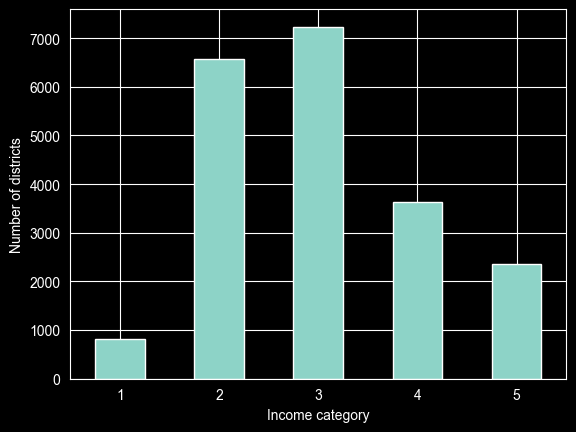

In [15]:
import matplotlib.pyplot as plt

# 把连续的收入变量离散化， 最终得到的新列，是一个类别型变量（Categorical）housing["income_cat"]。
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0, 1.5, 3.0, 4.5, 6., np.inf], # 把收入划分为不同区间，np.inf 表示正无穷
                               labels=[1, 2, 3, 4, 5]) # 给每个区间一个离散标签

print(housing["income_cat"].value_counts().sort_index())

# 1.统计每个收入类别出现的次数（.value_counts()）；2.按类别顺序排序（.sort_index()）；3.绘制柱状图，rot=0：x 轴标签不旋转（保持竖直）
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [9]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3
